In [106]:
import os
import csv
import h5py
import joblib
import pickle
import numpy as np
from pykdtree.kdtree import KDTree
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

def get_feature_list_hsmp(max_mcsh_order, step_size, max_r):
    """
    Generates lists of filenames for spin paired HSMP files based on given MCSH parameters.
    Iterates over spherical harmonics orders and cutoff radii.

    :param max_mcsh_order: Maximum order of spherical harmonics.
    :param step_size: Step size for the radial cutoff.
    :param max_r: Maximum radial cutoff.
    :return: list of filenames. 
    """
    hsmp_filenames = []
    for l in range(max_mcsh_order + 1):
        rcut = step_size
        while rcut <= max_r:
            filename = f"HSMP_l_{l}_rcut_{rcut:.6f}_spin_typ_0.csv"
            hsmp_filenames.append(filename)
            rcut += step_size
    return hsmp_filenames

def read_hdf5_data(filepath, num_features, 
                    hsmp_filenames):
    """Read data from an HDF5 file and return a numpy array."""
    with h5py.File(filepath, 'r') as data:
        functional_grp = data["functional_database/PBE"]
        return functional_grp["filtered_feature"][:]

def extract_mcsh_data(data, step_size, mcsh_order, rcut, mcsh_max_order, max_rcut):
    """
    Extracts columns of data corresponding to MCSH order and rcut specified.
    Also includes the first two columns of input data.
    """
    if mcsh_order > mcsh_max_order or rcut > max_rcut:
        raise ValueError("New order or max R must be less than or equal to the original values")

    num_r_values = int(max_rcut/ step_size)
    col_indices = [0, 1]
    for order in range(mcsh_order + 1):
        for r_index in range(num_r_values):
            r_value = (r_index + 1) * step_size
            if r_value > rcut:
                break
            col_index = 2 + order * num_r_values + r_index
            col_indices.append(col_index)
    return data[:, col_indices]

In [107]:
def partition(data, refdata, max_distance):
    kd_tree = KDTree(refdata,leafsize=6)
    temp_distances, temp_indices = kd_tree.query(data, k=1)
    indices = []
    for i, distance in enumerate(temp_distances): 
        if distance <= max_distance:
            indices.append(temp_indices[i])
        else:
            indices.append(-1)
    indices = np.array(indices)
    #count_minus_one = np.sum(indices == -1)
    #print(f"minus 1 occurance: {count_minus_one}")
    indices_reduced, counts = np.unique(indices, return_counts=True)
    #print(indices_reduced)
    count_arr = np.zeros(len(refdata)+1) 
    for i, index in enumerate(indices_reduced):
        count_arr[index] = counts[i] 
    #print(count_arr)
    return count_arr

In [108]:
def feature_scaling(feature_arr, mcsh_order, mcsh_step, mcsh_r):
    rcut = np.arange(mcsh_step, mcsh_r + mcsh_step, mcsh_step)
    mcsh_order_list = np.arange(0, mcsh_order + 1, 1)
    index = 2
    for order in mcsh_order_list:
        for rc in rcut:
            feature_arr[:, index] = feature_arr[:, index] * (rc**3)
            index += 1
    return feature_arr

In [109]:
max_distance_dict = {"mcsh_0_rcut_0.5": {"overall_0.075_sys_0.1": 0.117715795026257},
                    "mcsh_0_rcut_1.0": {"overall_0.075_sys_0.02": 0.436412777309289},
                    "mcsh_0_rcut_1.5": {"overall_0.075_sys_0.02": 0.240047405531602},
                    "mcsh_0_rcut_2.0": {"overall_0.075_sys_0.02": 0.126018332930656},
                    "mcsh_2_rcut_0.5": {"overall_0.075_sys_0.2": 1.52566166650721},
                    "mcsh_2_rcut_1.0": {"overall_0.075_sys_0.5": 1.54850567974646},
                    "mcsh_2_rcut_1.5": {"overall_0.075_sys_0.5": 1.72909873161774},
                    "mcsh_2_rcut_2.0": {"overall_0.1_sys_0.075": 1.52371145483616},
                    "mcsh_2_rcut_4.0": {"overall_0.1_sys_0.075": 2.09912763358924},
                    "mcsh_4_rcut_0.5": {"overall_0.2_sys_0.05": 1.63747741350728},
                    "mcsh_4_rcut_1.0": {"overall_0.1_sys_0.5": 2.69997903090385}, 
                    "mcsh_4_rcut_1.5": {"overall_0.1_sys_0.5": 3.05550566640858},
                    "mcsh_4_rcut_2.0": {"overall_0.2_sys_0.1": 1.55610033659168},
                    "mcsh_4_rcut_4.0": {"overall_0.075_sys_0.5": 2.29705445672651}}

In [110]:
def calculate_ads_corr(overall_sig, sys_sig, mcsh_order, mcsh_step, mcsh_r):
    
    model_basepath = "/storage/home/hcoda1/0/ssahoo41/cedar_storage/ssahoo41/exact_exchange_work/thesis_datagen/publication_purpose/training_script/best_models/train_best_model"
    refdata_path = f"/storage/home/hcoda1/0/ssahoo41/cedar_storage/ssahoo41/exact_exchange_work/thesis_datagen/publication_purpose/subsampling_script/overall_subsample/overall_subsample_True/mcsh_{mcsh_order}_rcut_{mcsh_r}/subsampled_{overall_sig}_system_{sys_sig}.pkl"
    refdata = pickle.load(open(refdata_path, "rb"))
    refdata = np.array(refdata)
    scaler = StandardScaler()
    refdata_scaled = scaler.fit_transform(refdata)
    
    scaler_path = os.path.join(model_basepath, f"mcsh_{mcsh_order}_rcut_{mcsh_r}", f"model_all_{overall_sig}_sys_{sys_sig}_lasso", "scaler.pkl")
    scaler_file = pickle.load(open(scaler_path, "rb"))
    model = joblib.load(os.path.join(model_basepath, f"mcsh_{mcsh_order}_rcut_{mcsh_r}", f"model_all_{overall_sig}_sys_{sys_sig}_lasso", "best_lasso_model.joblib"))
    metals = ["Cu", "Pt", "Rh"]
    sites = ["bridge", "fcc", "hcp", "ontop"]
    base_path = "/storage/home/hcoda1/0/ssahoo41/cedar_storage/ssahoo41/descriptor_data/pbe0_densities/hdf5_ads_v2_data/"
    
    max_distance = max_distance_dict[f"mcsh_{mcsh_order}_rcut_{mcsh_r}"][f"overall_{overall_sig}_sys_{sys_sig}"]
    mol_filepath = os.path.join(base_path, "molecule/CO_HSMP_l_4_rcut_4.000000.h5")
    mol_feat = read_hdf5_data(mol_filepath, num_features, hsmp_filenames)
    feat_extract = extract_mcsh_data(mol_feat, mcsh_step, mcsh_order, mcsh_r, 4, 4.0)
    mol_arr = feature_scaling(feat_extract, mcsh_order, mcsh_step, mcsh_r)
    
    mol_arr_scaled = scaler.transform(mol_arr)
    mol_count_arr = partition(mol_arr_scaled, refdata_scaled, max_distance=max_distance)
    mol_count_scaled = scaler_file.transform(mol_count_arr[:-1].reshape(1,-1))
    y_mol = model.predict(mol_count_scaled)
    
    ads_corr_dict = {"Cu": {}, "Pt": {}, "Rh": {}}
    for metal in metals:
        slab_filepath = os.path.join(base_path, "slab", f"{metal}_HSMP_l_4_rcut_4.000000.h5")
        slab_feat = read_hdf5_data(slab_filepath, num_features, hsmp_filenames)
        feat_extract = extract_mcsh_data(slab_feat, mcsh_step, mcsh_order, mcsh_r, 4, 4.0)
        slab_arr = feature_scaling(feat_extract, mcsh_order, mcsh_step, mcsh_r)
        slab_arr_scaled = scaler.transform(slab_arr)
        slab_count_arr = partition(slab_arr_scaled, refdata_scaled, max_distance=max_distance)
        slab_scaled = scaler_file.transform(slab_count_arr[:-1].reshape(1,-1))
        y_slab = model.predict(slab_scaled) 
        
        for site in sites:
            ads_filepath = os.path.join(base_path, "slab_ads", f"{metal}_{site}_HSMP_l_4_rcut_4.000000.h5")
            ads_feat = read_hdf5_data(ads_filepath, num_features, hsmp_filenames)
            feat_extract = extract_mcsh_data(ads_feat, mcsh_step, mcsh_order, mcsh_r, 4, 4.0)
            ads_arr = feature_scaling(feat_extract, mcsh_order, mcsh_step, mcsh_r)
            ads_arr_scaled = scaler.transform(ads_arr)
            ads_count_arr = partition(ads_arr_scaled, refdata_scaled, max_distance=max_distance)
            ads_scaled = scaler_file.transform(ads_count_arr[:-1].reshape(1,-1))
            y_ads = model.predict(ads_scaled) 
            ads_en_corr = y_ads - y_slab - y_mol
            ads_corr_dict[metal][site] = ads_en_corr
            
    return ads_corr_dict

In [111]:
mcsh_max_order, mcsh_step_size, mcsh_max_r = 4, 0.5, 0.5
overall_sig = 0.2
sys_sig = 0.05
hsmp_filenames = get_feature_list_hsmp(mcsh_max_order, mcsh_step_size, mcsh_max_r)
num_features = len(hsmp_filenames)
ads_corr_dict_4_5 = calculate_ads_corr(overall_sig, sys_sig, mcsh_max_order, mcsh_step_size, mcsh_max_r)

In [112]:
mcsh_max_order, mcsh_step_size, mcsh_max_r = 4, 0.5, 1.0
overall_sig = 0.1
sys_sig = 0.5
hsmp_filenames = get_feature_list_hsmp(mcsh_max_order, mcsh_step_size, mcsh_max_r)
num_features = len(hsmp_filenames)
ads_corr_dict_4_1 = calculate_ads_corr(overall_sig, sys_sig,mcsh_max_order, mcsh_step_size, mcsh_max_r)

In [113]:
mcsh_max_order, mcsh_step_size, mcsh_max_r = 4, 0.5, 1.5
overall_sig = 0.1
sys_sig = 0.5
hsmp_filenames = get_feature_list_hsmp(mcsh_max_order, mcsh_step_size, mcsh_max_r)
num_features = len(hsmp_filenames)
ads_corr_dict_4_15 = calculate_ads_corr(overall_sig, sys_sig,mcsh_max_order, mcsh_step_size, mcsh_max_r)

In [114]:
mcsh_max_order, mcsh_step_size, mcsh_max_r = 4, 0.5, 2.0
overall_sig = 0.2
sys_sig = 0.1
hsmp_filenames = get_feature_list_hsmp(mcsh_max_order, mcsh_step_size, mcsh_max_r)
num_features = len(hsmp_filenames)
ads_corr_dict_4_2 = calculate_ads_corr(overall_sig, sys_sig,mcsh_max_order, mcsh_step_size, mcsh_max_r)

In [115]:
mcsh_max_order, mcsh_step_size, mcsh_max_r = 4, 0.5, 4.0
overall_sig = 0.075
sys_sig = 0.5
hsmp_filenames = get_feature_list_hsmp(mcsh_max_order, mcsh_step_size, mcsh_max_r)
num_features = len(hsmp_filenames)
ads_corr_dict_4_4 = calculate_ads_corr(overall_sig, sys_sig,mcsh_max_order, mcsh_step_size, mcsh_max_r)

In [116]:
molecule_en = {"CO": -2.2507805112E+01}
slab_en = {"Cu": -2.9217079454E+03, "Pt": -1.8877610825E+03, "Rh": -1.7365404612E+03}

ads_slab_en = {"Cu": {"bridge": -2.9442454256E+03, "fcc": -2.9442451969E+03, "hcp": -2.9442454142E+03, "ontop": -2.9442424768E+03},
              "Pt": {"bridge": -1.9103306329E+03, "fcc": -1.9103306033E+03, "hcp": -1.9103304157E+03, "ontop": -1.9103292561E+03},
              "Rh": {"bridge": -1.7591191816E+03, "fcc": -1.7591158330E+03, "hcp": -1.7591191746E+03, "ontop": -1.7591172124E+03}}

In [117]:
metals = ["Cu", "Pt", "Rh"]
sites = ["bridge", "fcc", "hcp", "ontop"]
ads_energy_dict = {"Cu": {}, "Pt": {}, "Rh": {}}
pbe_ads_energy = {"Cu": {}, "Pt": {}, "Rh": {}}
for metal in metals:
    for site in sites:
        #ads_energy = (ads_slab_en[metal][site] - slab_en[metal] - molecule_en["CO"])*27.2114 + ads_corr_dict[metal][site]
        #ads_energy_dict[metal][site] = ads_energy
        pbe_ads_energy[metal][site] = (ads_slab_en[metal][site] - slab_en[metal] - molecule_en["CO"])*27.2114

In [118]:
ads_energy_4_5_dict = {"Cu": {}, "Pt": {}, "Rh": {}}
ads_energy_4_1_dict = {"Cu": {}, "Pt": {}, "Rh": {}}
ads_energy_4_15_dict = {"Cu": {}, "Pt": {}, "Rh": {}}
ads_energy_4_2_dict = {"Cu": {}, "Pt": {}, "Rh": {}}
ads_energy_4_4_dict = {"Cu": {}, "Pt": {}, "Rh": {}}

for metal in metals:
    for site in sites:
        ads_energy = (ads_slab_en[metal][site] - slab_en[metal] - molecule_en["CO"])*27.2114 + ads_corr_dict_4_5[metal][site]
        ads_energy_4_5_dict[metal][site] = ads_energy
        ads_energy = (ads_slab_en[metal][site] - slab_en[metal] - molecule_en["CO"])*27.2114 + ads_corr_dict_4_1[metal][site]
        ads_energy_4_1_dict[metal][site] = ads_energy
        ads_energy = (ads_slab_en[metal][site] - slab_en[metal] - molecule_en["CO"])*27.2114 + ads_corr_dict_4_15[metal][site]
        ads_energy_4_15_dict[metal][site] = ads_energy
        ads_energy = (ads_slab_en[metal][site] - slab_en[metal] - molecule_en["CO"])*27.2114 + ads_corr_dict_4_2[metal][site]
        ads_energy_4_2_dict[metal][site] = ads_energy
        ads_energy = (ads_slab_en[metal][site] - slab_en[metal] - molecule_en["CO"])*27.2114 + ads_corr_dict_4_4[metal][site]
        ads_energy_4_4_dict[metal][site] = ads_energy

In [119]:
Cu_ads = -0.590519
Pt_ads = -124*0.01036
Rh_ads = -142*0.01036

In [120]:
metals = ["Cu", "Pt", "Rh"]
sites = ["bridge", "ontop", "hcp", "fcc"]

molecule_energy_dict = {"PBE":-2.2507805112E+01, "RPBE": -2.2542403126E+01, "WC":-2.2484533309E+01}
Cu_slab_energy_dict = {"PBE":-2.9217079454E+03, "RPBE":-2.9226059051E+03, "WC":-2.9210563271E+03}
Pt_slab_energy_dict = {"PBE":-1.8877610825E+03, "RPBE": -1.8880621693E+03, "WC":-1.8875261389E+03}
Rh_slab_energy_dict = {"PBE":-1.7365404612E+03, "RPBE": -1.7368844981E+03, "WC":-1.7362764923E+03}

Cu_slab_ads_dict = {"bridge":{"PBE": -2.9442454256E+03, "RPBE": -2.9451647502E+03, "WC": -2.9435787805E+03},
                   "fcc":{"PBE": -2.9442451969E+03, "RPBE": -2.9451646548E+03, "WC": -2.9435784610E+03},
                   "hcp":{"PBE": -2.9442454142E+03, "RPBE": -2.9451647021E+03, "WC": -2.9435787560E+03},
                    "ontop":{"PBE": -2.9442424768E+03, "RPBE": -2.9451644807E+03, "WC": -2.9435740827E+03}}

Pt_slab_ads_dict = {"bridge":{"PBE":-1.9103306329E+03, "RPBE":-1.9106534804E+03, "WC":-1.9100802537E+03},
                   "fcc":{"PBE":-1.9103306033E+03, "RPBE": -1.9106526823E+03, "WC": -1.9100807197E+03},
                   "hcp":{"PBE":-1.9103304157E+03, "RPBE": -1.9106526162E+03, "WC": -1.9100808916E+03},
                   "ontop":{"PBE": -1.9103292561E+03, "RPBE": -1.9106534405E+03, "WC": -1.9100780829E+03}}

Rh_slab_ads_dict = {"bridge":{"PBE":-1.7591191816E+03, "RPBE":-1.7594840505E+03, "WC":-1.7588407804E+03},
                   "fcc":{"PBE":-1.7591158330E+03, "RPBE":-1.7594811151E+03, "WC": -1.7588370953E+03},
                   "hcp":{"PBE":-1.7591191746E+03, "RPBE": -1.7594841599E+03, "WC": -1.7588407114E+03},
                   "ontop":{"PBE": -1.7591172124E+03, "RPBE": -1.7594860414E+03, "WC": -1.7588362263E+03}}

Cu_ads_energy_dict = {}
Pt_ads_energy_dict = {}
Rh_ads_energy_dict = {}

functionals = ["PBE", "RPBE", "WC"]
for metal in metals:
    for site in sites:
        for functional in functionals:
            if metal == "Cu":
                Cu_ads_energy_dict[site, functional] = (Cu_slab_ads_dict[site][functional] - Cu_slab_energy_dict[functional] - molecule_energy_dict[functional])*27.2114
            if metal == "Pt":
                Pt_ads_energy_dict[site, functional] = (Pt_slab_ads_dict[site][functional] - Pt_slab_energy_dict[functional] - molecule_energy_dict[functional])*27.2114
            if metal == "Rh":
                Rh_ads_energy_dict[site, functional] = (Rh_slab_ads_dict[site][functional] - Rh_slab_energy_dict[functional] - molecule_energy_dict[functional])*27.2114

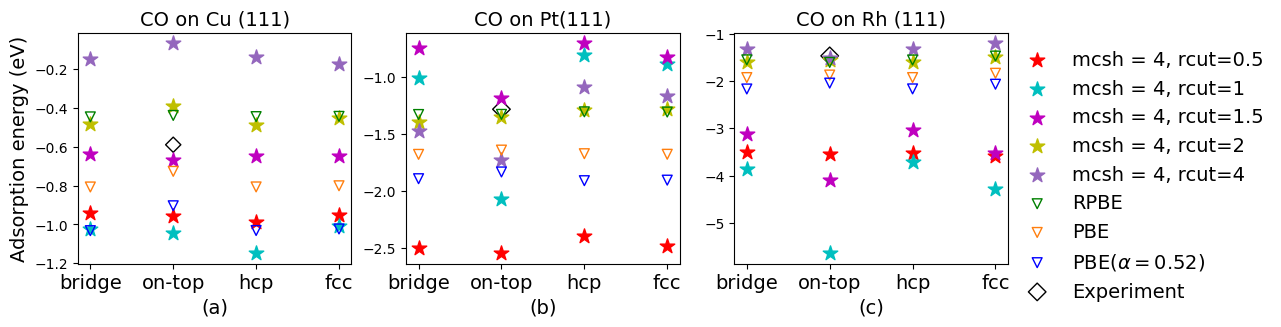

In [121]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1,3,figsize=(12, 3))
font_size = 14

axes[0].scatter("bridge", ads_energy_4_5_dict["Cu"]["bridge"], color="r", marker="*", s = 120)
axes[0].scatter("bridge", ads_energy_4_1_dict["Cu"]["bridge"], color="c", marker="*", s = 120)
axes[0].scatter("bridge", ads_energy_4_15_dict["Cu"]["bridge"], color="m", marker="*", s = 120)
axes[0].scatter("bridge", ads_energy_4_2_dict["Cu"]["bridge"], color="y", marker="*", s = 120)
axes[0].scatter("bridge", ads_energy_4_4_dict["Cu"]["bridge"], color="tab:purple", marker="*", s = 120)

axes[0].scatter("bridge", Cu_ads_energy_dict[("bridge", "RPBE")], facecolors='none', edgecolors="g", label= "RPBE", s=50, marker="v")
axes[0].scatter("bridge", Cu_ads_energy_dict[("bridge", "PBE")], facecolors='none', edgecolors="tab:orange", label="PBE", s=50, marker="v")
axes[0].scatter("bridge", Cu_ads_energy_dict[("bridge", "WC")], facecolors='none', edgecolors="b", label="WC", s=50, marker="v")

axes[0].scatter("on-top", Cu_ads, color="g", facecolors='none', edgecolors="k", marker="D", s = 60)
axes[0].scatter("on-top", ads_energy_4_5_dict["Cu"]["ontop"], color="r", marker="*", s = 120)
axes[0].scatter("on-top", ads_energy_4_1_dict["Cu"]["ontop"], color="c", marker="*", s = 120)
axes[0].scatter("on-top", ads_energy_4_15_dict["Cu"]["ontop"], color="m", marker="*", s = 120)
axes[0].scatter("on-top", ads_energy_4_2_dict["Cu"]["ontop"], color="y", marker="*", s = 120)
axes[0].scatter("on-top", ads_energy_4_4_dict["Cu"]["ontop"], color="tab:purple", marker="*", s = 120)

axes[0].scatter("on-top", Cu_ads_energy_dict[("ontop", "RPBE")], facecolors='none', edgecolors="g", s=50, marker="v")
axes[0].scatter("on-top", Cu_ads_energy_dict[("ontop", "PBE")], facecolors='none', edgecolors="tab:orange", s=50, marker="v")
axes[0].scatter("on-top", Cu_ads_energy_dict[("ontop", "WC")], facecolors='none', edgecolors="b", s=50, marker="v")

axes[0].scatter("hcp", ads_energy_4_5_dict["Cu"]["hcp"], color="r", marker="*", s = 120)
axes[0].scatter("hcp", ads_energy_4_1_dict["Cu"]["hcp"], color="c", marker="*", s = 120)
axes[0].scatter("hcp", ads_energy_4_15_dict["Cu"]["hcp"], color="m", marker="*", s = 120)
axes[0].scatter("hcp", ads_energy_4_2_dict["Cu"]["hcp"], color="y", marker="*", s = 120)
axes[0].scatter("hcp", ads_energy_4_4_dict["Cu"]["hcp"], color="tab:purple", marker="*", s = 120)

axes[0].scatter("hcp", Cu_ads_energy_dict[("hcp", "RPBE")], facecolors='none', edgecolors="g", s=50, marker="v")
axes[0].scatter("hcp", Cu_ads_energy_dict[("hcp", "PBE")], facecolors='none', edgecolors="tab:orange", s=50, marker="v")
axes[0].scatter("hcp", Cu_ads_energy_dict[("hcp", "WC")], facecolors='none', edgecolors="b", s=50, marker="v")

axes[0].scatter("fcc", ads_energy_4_5_dict["Cu"]["fcc"], color="r", marker="*", s = 120)
axes[0].scatter("fcc", ads_energy_4_1_dict["Cu"]["fcc"], color="c", marker="*", s = 120)
axes[0].scatter("fcc", ads_energy_4_15_dict["Cu"]["fcc"], color="m", marker="*", s = 120)
axes[0].scatter("fcc", ads_energy_4_2_dict["Cu"]["fcc"], color="y", marker="*", s = 120)
axes[0].scatter("fcc", ads_energy_4_4_dict["Cu"]["fcc"], color="tab:purple", marker="*", s = 120)

axes[0].scatter("fcc", Cu_ads_energy_dict[("fcc", "RPBE")], facecolors='none', edgecolors="g", s=50, marker="v")
axes[0].scatter("fcc", Cu_ads_energy_dict[("fcc", "PBE")], facecolors='none', edgecolors="tab:orange", s=50, marker="v")
axes[0].scatter("fcc", Cu_ads_energy_dict[("fcc", "WC")], facecolors='none', edgecolors="b", s=50, marker="v")
axes[0].tick_params(axis='x', labelsize=font_size)
axes[0].set_ylabel("Adsorption energy (eV)", fontsize=font_size)
axes[0].set_xlabel("(a)", fontsize=font_size)
axes[0].set_title("CO on Cu (111)", fontsize=font_size)


axes[1].scatter("bridge", ads_energy_4_5_dict["Pt"]["bridge"], color="r", marker="*", s = 120)
axes[1].scatter("bridge", ads_energy_4_1_dict["Pt"]["bridge"], color="c", marker="*", s = 120)
axes[1].scatter("bridge", ads_energy_4_15_dict["Pt"]["bridge"], color="m", marker="*", s = 120)
axes[1].scatter("bridge", ads_energy_4_2_dict["Pt"]["bridge"], color="y", marker="*", s = 120)
axes[1].scatter("bridge", ads_energy_4_4_dict["Pt"]["bridge"], color="tab:purple", marker="*", s = 120)

axes[1].scatter("bridge", Pt_ads_energy_dict[("bridge", "RPBE")], facecolors='none', edgecolors="g", s=50, marker="v")
axes[1].scatter("bridge", Pt_ads_energy_dict[("bridge", "PBE")], facecolors='none', edgecolors="tab:orange", s=50, marker="v")
axes[1].scatter("bridge", Pt_ads_energy_dict[("bridge", "WC")], facecolors='none', edgecolors="b", s=50, marker="v")

axes[1].scatter("on-top", Pt_ads, color="g", facecolors='none', edgecolors="k", marker="D", s = 80)
axes[1].scatter("on-top", ads_energy_4_5_dict["Pt"]["ontop"], color="r", marker="*", s = 120)
axes[1].scatter("on-top", ads_energy_4_1_dict["Pt"]["ontop"], color="c", marker="*", s = 120)
axes[1].scatter("on-top", ads_energy_4_15_dict["Pt"]["ontop"], color="m", marker="*", s = 120)
axes[1].scatter("on-top", ads_energy_4_2_dict["Pt"]["ontop"], color="y", marker="*", s = 120)
axes[1].scatter("on-top", ads_energy_4_4_dict["Pt"]["ontop"], color="tab:purple", marker="*", s = 120)

axes[1].scatter("on-top", Pt_ads_energy_dict[("ontop", "RPBE")], facecolors='none', edgecolors="g", s=50, marker="v")
axes[1].scatter("on-top", Pt_ads_energy_dict[("ontop", "PBE")], facecolors='none', edgecolors="tab:orange", s=50, marker="v")
axes[1].scatter("on-top", Pt_ads_energy_dict[("ontop", "WC")], facecolors='none', edgecolors="b", s=50, marker="v")

axes[1].scatter("hcp", ads_energy_4_5_dict["Pt"]["hcp"], color="r", marker="*", s = 120)
axes[1].scatter("hcp", ads_energy_4_1_dict["Pt"]["hcp"], color="c", marker="*", s = 120)
axes[1].scatter("hcp", ads_energy_4_15_dict["Pt"]["hcp"], color="m", marker="*", s = 120)
axes[1].scatter("hcp", ads_energy_4_2_dict["Pt"]["hcp"], color="y", marker="*", s = 120)
axes[1].scatter("hcp", ads_energy_4_4_dict["Pt"]["hcp"], color="tab:purple", marker="*", s = 120)

axes[1].scatter("hcp", Pt_ads_energy_dict[("hcp", "RPBE")], facecolors='none', edgecolors="g", s=50, marker="v")
axes[1].scatter("hcp", Pt_ads_energy_dict[("hcp", "PBE")], facecolors='none', edgecolors="tab:orange", s=50, marker="v")
axes[1].scatter("hcp", Pt_ads_energy_dict[("hcp", "WC")], facecolors='none', edgecolors="b", s=50, marker="v")

axes[1].scatter("fcc", ads_energy_4_5_dict["Pt"]["fcc"], color="r", marker="*", s = 120)
axes[1].scatter("fcc", ads_energy_4_1_dict["Pt"]["fcc"], color="c", marker="*", s = 120)
axes[1].scatter("fcc", ads_energy_4_15_dict["Pt"]["fcc"], color="m", marker="*", s = 120)
axes[1].scatter("fcc", ads_energy_4_2_dict["Pt"]["fcc"], color="y", marker="*", s = 120)
axes[1].scatter("fcc", ads_energy_4_4_dict["Pt"]["fcc"], color="tab:purple", marker="*", s = 120)

axes[1].scatter("fcc", Pt_ads_energy_dict[("fcc", "RPBE")], facecolors='none', edgecolors="g", s=50, marker="v")
axes[1].scatter("fcc", Pt_ads_energy_dict[("fcc", "PBE")], facecolors='none', edgecolors="tab:orange", s=50, marker="v")
axes[1].scatter("fcc", Pt_ads_energy_dict[("fcc", "WC")], facecolors='none', edgecolors="b", s=50, marker="v")

axes[1].tick_params(axis='x', labelsize=font_size)
axes[1].set_xlabel("(b)", fontsize=font_size)
axes[1].set_title("CO on Pt(111)", fontsize=font_size)

axes[2].scatter("bridge", ads_energy_4_5_dict["Rh"]["bridge"], color="r", marker="*", s = 120, label="mcsh = 4, rcut=0.5")
axes[2].scatter("bridge", ads_energy_4_1_dict["Rh"]["bridge"], color="c", marker="*", s = 120, label="mcsh = 4, rcut=1")
axes[2].scatter("bridge", ads_energy_4_15_dict["Rh"]["bridge"], color="m", marker="*", s = 120, label="mcsh = 4, rcut=1.5")
axes[2].scatter("bridge", ads_energy_4_2_dict["Rh"]["bridge"], color="y", marker="*", s = 120, label="mcsh = 4, rcut=2")
axes[2].scatter("bridge", ads_energy_4_4_dict["Rh"]["bridge"], color="tab:purple", marker="*", s = 120, label="mcsh = 4, rcut=4")

axes[2].scatter("bridge", Rh_ads_energy_dict[("bridge", "RPBE")], facecolors='none', edgecolors="g", label="RPBE", s=50, marker="v")
axes[2].scatter("bridge", Rh_ads_energy_dict[("bridge", "PBE")], facecolors='none', edgecolors="tab:orange", label="PBE", s=50, marker="v")
axes[2].scatter("bridge", Rh_ads_energy_dict[("bridge", "WC")], facecolors='none', edgecolors="b", label=r"PBE($\alpha=0.52$)", s=50, marker="v")

axes[2].scatter("on-top", Rh_ads, color="g", facecolors='none', edgecolors="k", marker="D", s = 80, label="Experiment")
axes[2].scatter("on-top", ads_energy_4_5_dict["Rh"]["ontop"], color="r", marker="*", s = 120)
axes[2].scatter("on-top", ads_energy_4_1_dict["Rh"]["ontop"], color="c", marker="*", s = 120)
axes[2].scatter("on-top", ads_energy_4_15_dict["Rh"]["ontop"], color="m", marker="*", s = 120)
axes[2].scatter("on-top", ads_energy_4_2_dict["Rh"]["ontop"], color="y", marker="*", s = 120)
axes[2].scatter("on-top", ads_energy_4_4_dict["Rh"]["ontop"], color="tab:purple", marker="*", s = 120)

axes[2].scatter("on-top", Rh_ads_energy_dict[("ontop", "RPBE")], facecolors='none', edgecolors="g", s=50, marker="v")
axes[2].scatter("on-top", Rh_ads_energy_dict[("ontop", "PBE")], facecolors='none', edgecolors="tab:orange", s=50, marker="v")
axes[2].scatter("on-top", Rh_ads_energy_dict[("ontop", "WC")], facecolors='none', edgecolors="b", s=50, marker="v")

axes[2].scatter("hcp", ads_energy_4_5_dict["Rh"]["hcp"], color="r", marker="*", s = 120)
axes[2].scatter("hcp", ads_energy_4_1_dict["Rh"]["hcp"], color="c", marker="*", s = 120)
axes[2].scatter("hcp", ads_energy_4_15_dict["Rh"]["hcp"], color="m", marker="*", s = 120)
axes[2].scatter("hcp", ads_energy_4_2_dict["Rh"]["hcp"], color="y", marker="*", s = 120)
axes[2].scatter("hcp", ads_energy_4_4_dict["Rh"]["hcp"], color="tab:purple", marker="*", s = 120)

axes[2].scatter("hcp", Rh_ads_energy_dict[("hcp", "RPBE")], facecolors='none', edgecolors="g", s=50, marker="v")
axes[2].scatter("hcp", Rh_ads_energy_dict[("hcp", "PBE")], facecolors='none', edgecolors="tab:orange", s=50, marker="v")
axes[2].scatter("hcp", Rh_ads_energy_dict[("hcp", "WC")], facecolors='none', edgecolors="b", s=50, marker="v")

axes[2].scatter("fcc", ads_energy_4_5_dict["Rh"]["fcc"], color="r", marker="*", s = 120)
axes[2].scatter("fcc", ads_energy_4_1_dict["Rh"]["fcc"], color="c", marker="*", s = 120)
axes[2].scatter("fcc", ads_energy_4_15_dict["Rh"]["fcc"], color="m", marker="*", s = 120)
axes[2].scatter("fcc", ads_energy_4_2_dict["Rh"]["fcc"], color="y", marker="*", s = 120)
axes[2].scatter("fcc", ads_energy_4_4_dict["Rh"]["fcc"], color="tab:purple", marker="*", s = 120)

axes[2].scatter("fcc", Rh_ads_energy_dict[("fcc", "RPBE")], facecolors='none', edgecolors="g", s=50, marker="v")
axes[2].scatter("fcc", Rh_ads_energy_dict[("fcc", "PBE")], facecolors='none', edgecolors="tab:orange", s=50, marker="v")
axes[2].scatter("fcc", Rh_ads_energy_dict[("fcc", "WC")], facecolors='none', edgecolors="b", s=50, marker="v")

axes[2].set_xlabel("(c)", fontsize=font_size)
axes[2].tick_params(axis='x', labelsize=font_size)
axes[2].set_title("CO on Rh (111)", fontsize=font_size)
plt.legend(loc="upper right", bbox_to_anchor=(2,1),frameon=False, fontsize=font_size)
#plt.savefig("adsorption_en_correction.png", bbox_inches="tight", dpi=600)